In [7]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid, plotScalarFunction
from dolfinx.fem import functionspace, Function
import pickle

In [8]:
# Set up geometry
height = 2
length = 1
delta_x = delta_z = 0.1
nx = int(6/delta_x)
nz = int(3/delta_x)
geom = Geometry(height, length, slope=0)
domain = geom.make_domain(nx, nz)
V_hw = functionspace(domain, ("CG", 1))
h_w = Function(V_hw)
h_w.x.array[:] = np.load("./solutions/isothermal.npy")

2026-06-18 09:26:03.679 (   2.345s) [    798641FC6600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


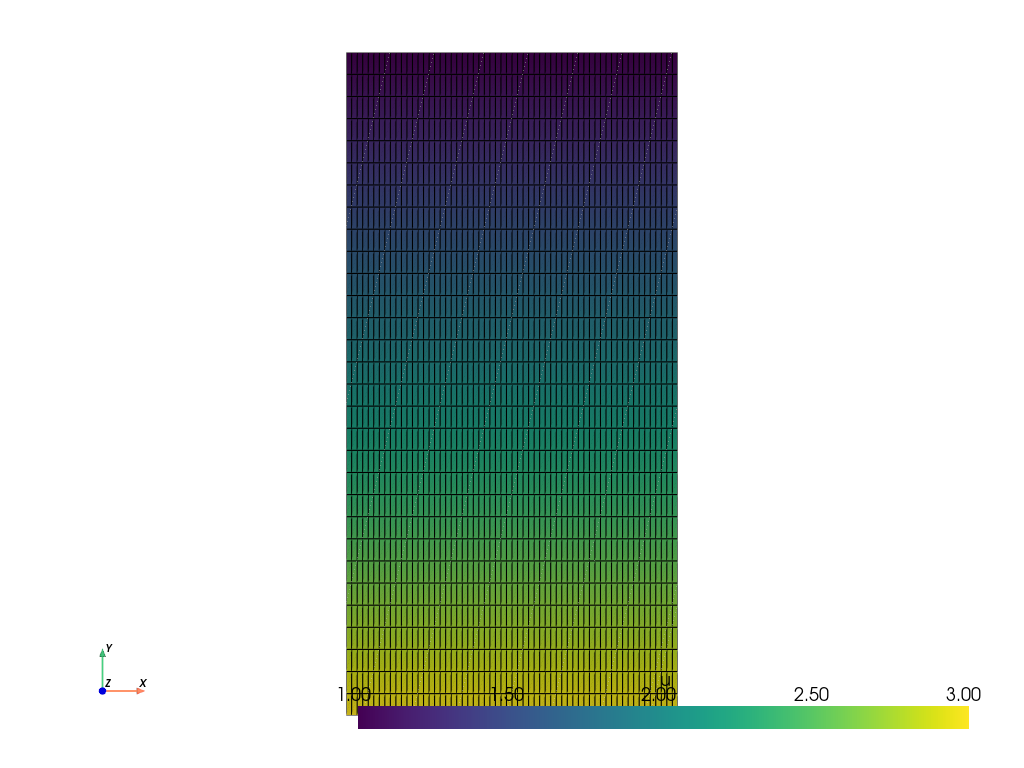

In [3]:
plotScalarFunction(V_hw, h_w)

In [9]:
filename = "./solutions/pls_work.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(V)
p = Parameter(domain)
print(P0, P1, P2, P3)

[0 0] [ 6. -1.] [6. 2.] [0 3]


In [10]:
hw.x.array[:] = data_Annika["h_w"][10]
phi.x.array[:] = data_Annika["phi"]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
theta = Function(V)
theta.x.array[:] = p.theta_numerical(p.S_e_numerical(hw), phi)
LWC = eval_fct_on_grid(grid, theta, domain).reshape((nz, nx))
h_tot = pressure_head + grid[:,1].reshape((nz, nx))

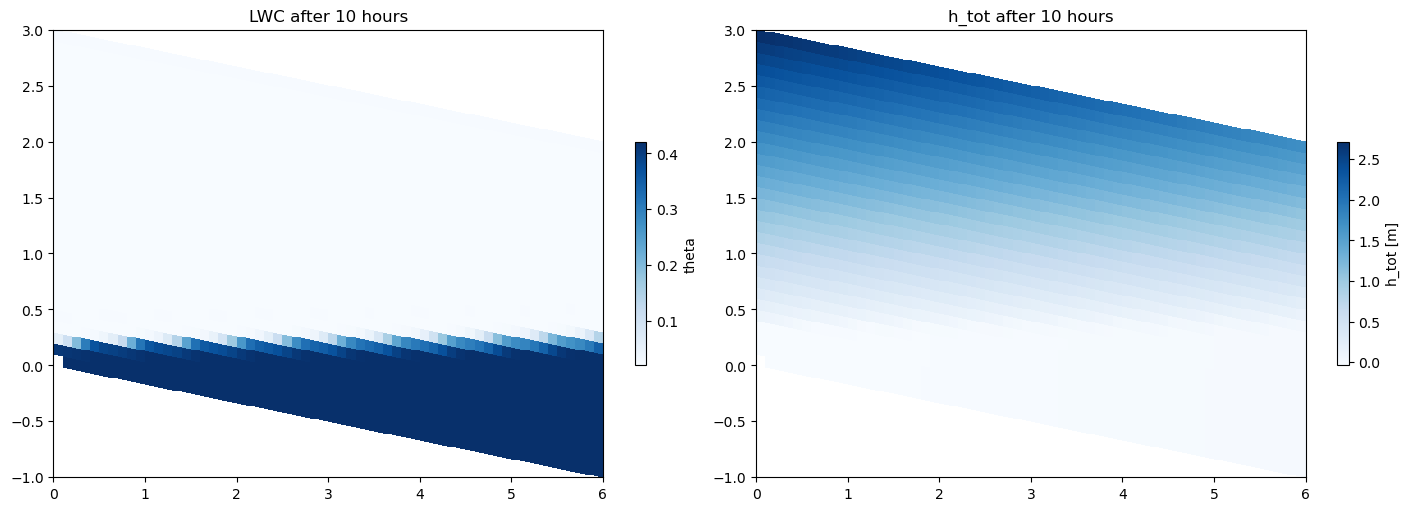

In [11]:
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, LWC, cmap="Blues")
ax[0].set_title(f"LWC after 10 hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after 10 hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [23]:
p.S_e_numerical(hw)[-1]

np.float64(4.16786441100732e-06)

In [27]:
print(f"{(3*(p.d_i.value/2)**2*np.exp(-0.013*p.rho_i.value*(1-0.468))*p.rho_w.value*p.g.value/p.mu_w.value):.3e}")

6.859e-04
